In [1]:
import torch
import torch.nn as nn
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
import ast

#Since cross attention is directional -> drug1 attends to drug2 ≠ drug2 attends to drug1
#So we do bi-directional cross attention and then combine the outputs together (we're using concat for that)

In [2]:
# Pair embedding (DETERMINISTIC)
# The earlier cross-attention block was untrained (random weights), which hurts performance.
# Use a strong symmetric composition that downstream models can exploit:
# [e1, e2, |e1-e2|, e1*e2] then (optionally) PCA -> 256D.


def compose_pair_features(e1: torch.Tensor, e2: torch.Tensor) -> torch.Tensor:
    e1 = torch.nn.functional.normalize(e1, p=2, dim=-1)
    e2 = torch.nn.functional.normalize(e2, p=2, dim=-1)
    return torch.cat([e1, e2, (e1 - e2).abs(), (e1 * e2)], dim=-1)

In [3]:
# Full pipeline
# Load fused per-drug embeddings (SMILES -> embedding)
fused_dict = torch.load("drug_fused_embeddings_with_unmapped_fallback.pt", map_location="cpu")

# Load dataset
df = pd.read_csv("final_processed_data.csv")

# Convert string list -> actual list
df["Side Effect Name"] = df["Side Effect Name"].apply(ast.literal_eval)

# Build labels
mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(df["Side Effect Name"])  # (N, C)

pair_feats = []
valid_labels = []

print(f"Total rows: {len(df)}")

for i in tqdm(range(len(df)), desc="Processing pairs"):
    s1 = df.iloc[i]["SMILES1"]
    s2 = df.iloc[i]["SMILES2"]

    if s1 not in fused_dict or s2 not in fused_dict:
        continue

    e1 = fused_dict[s1].float().unsqueeze(0)
    e2 = fused_dict[s2].float().unsqueeze(0)

    with torch.no_grad():
        feats = compose_pair_features(e1, e2)

    pair_feats.append(feats.squeeze(0).cpu().numpy())
    valid_labels.append(labels[i])

pair_feats = np.asarray(pair_feats, dtype=np.float32)
y = torch.from_numpy(np.asarray(valid_labels, dtype=np.float32))

# Optional PCA -> 256D output (recommended)
try:
    from sklearn.decomposition import PCA

    pca = PCA(n_components=256, random_state=42)
    X = torch.from_numpy(pca.fit_transform(pair_feats).astype(np.float32))
    X = torch.nn.functional.normalize(X, p=2, dim=-1)
    print("Used PCA ->", X.shape)
except Exception:
    X = torch.from_numpy(pair_feats)
    print("PCA not available, using raw composed features ->", X.shape)

print("Final tensors:", X.shape, y.shape)

C:\Users\mg276\AppData\Local\Temp\ipykernel_24888\116047995.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fused_dict = torch.load("drug_fused_embeddings_with_unmapped_

Total rows: 63304


Processing pairs: 100%|██████████| 63304/63304 [00:06<00:00, 10397.53it/s]


Used PCA -> torch.Size([63304, 256])
Final tensors: torch.Size([63304, 256]) torch.Size([63304, 963])


In [4]:
# Save in the format expected by gnn/graph.ipynb
side_effects_map = {name: int(i) for i, name in enumerate(mlb.classes_)}

bundle = {
    "X": X,
    "y": y,
    "Side effects": side_effects_map,
}

# Save locally (embedding_codes/) and also into gnn/ for training
import os

torch.save(bundle, "./pair_embeddings_with_unmapped_fallback.pt")
os.makedirs("../gnn", exist_ok=True)
torch.save(bundle, "../gnn/pair_embeddings_with_unmapped_fallback.pt")

print("Done!")
print("Final shape:", X.shape, y.shape)

Done!
Final shape: torch.Size([63304, 256]) torch.Size([63304, 963])


Embedding quality

In [5]:
import torch
import torch.nn.functional as F

# Safe conversion: works whether X is numpy or tensor
if isinstance(X, torch.Tensor):
    X = X.float()
else:
    X = torch.from_numpy(X).float()

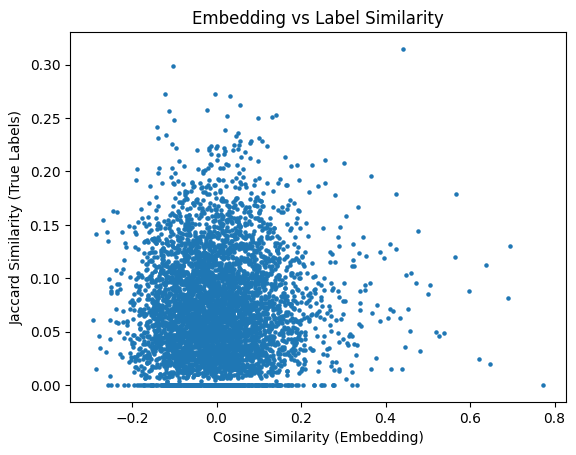

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

def jaccard(a, b):
    inter = np.sum(a * b)
    union = np.sum((a + b) > 0)
    return inter / union if union > 0 else 0

scores = []
labels_sim = []

N = X.shape[0]

for _ in range(5000):  # sample for speed
    i, j = np.random.randint(0, N, 2)
    if i == j:
        continue

    # embedding similarity
    sim = F.cosine_similarity(
        X[i].unsqueeze(0),
        X[j].unsqueeze(0)
    ).item()

    # ground truth similarity
    jac = jaccard(y[i].numpy(), y[j].numpy())

    scores.append(sim)
    labels_sim.append(jac)

plt.figure()
plt.scatter(scores, labels_sim, s=5)
plt.xlabel("Cosine Similarity (Embedding)")
plt.ylabel("Jaccard Similarity (True Labels)")
plt.title("Embedding vs Label Similarity")
plt.show()

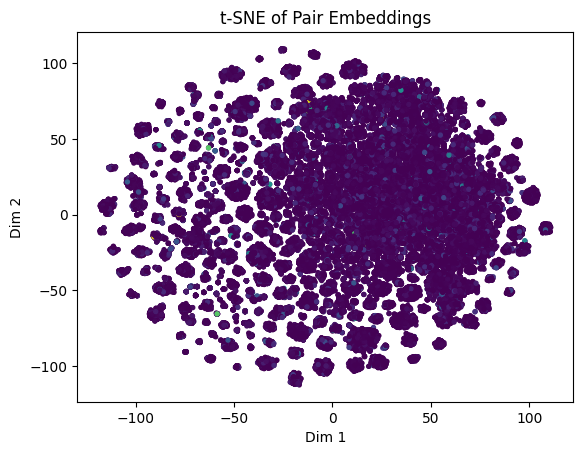

In [7]:
from sklearn.manifold import TSNE

# reduce labels to single class (for coloring)
labels_vis = np.argmax(y.numpy(), axis=1)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X.numpy())

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_vis, s=8)
plt.title("t-SNE of Pair Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

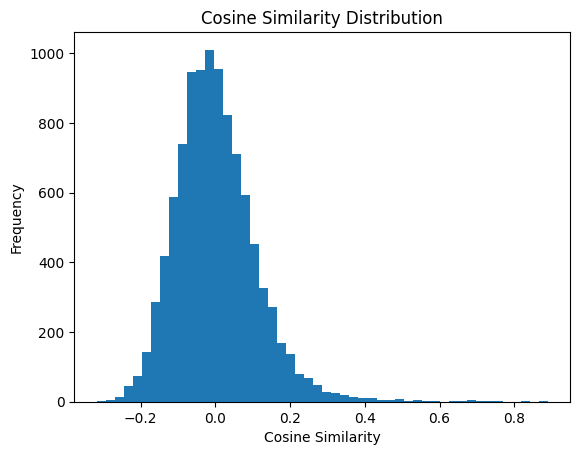

In [8]:
sims = []

for _ in range(10000):
    i, j = np.random.randint(0, N, 2)
    sims.append(F.cosine_similarity(
        X[i].unsqueeze(0),
        X[j].unsqueeze(0)
    ).item())

plt.figure()
plt.hist(sims, bins=50)
plt.title("Cosine Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()

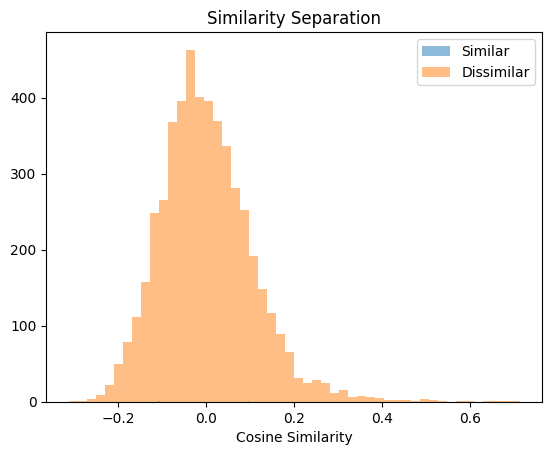

In [9]:
sim_scores = []
binary_labels = []

for _ in range(5000):
    i, j = np.random.randint(0, N, 2)
    if i == j:
        continue

    sim = F.cosine_similarity(
        X[i].unsqueeze(0),
        X[j].unsqueeze(0)
    ).item()

    jac = jaccard(y[i].numpy(), y[j].numpy())

    sim_scores.append(sim)
    binary_labels.append(1 if jac > 0.3 else 0)

sim_scores = np.array(sim_scores)
binary_labels = np.array(binary_labels)

plt.figure()
plt.hist(sim_scores[binary_labels==1], bins=50, alpha=0.5, label="Similar")
plt.hist(sim_scores[binary_labels==0], bins=50, alpha=0.5, label="Dissimilar")
plt.legend()
plt.title("Similarity Separation")
plt.xlabel("Cosine Similarity")
plt.show()

In [11]:
data=torch.load("pair_embeddings_mapped_only.pt")
X=data["X"]
print("Final shape:", X.shape)

Final shape: torch.Size([48006, 256])


C:\Users\mg276\AppData\Local\Temp\ipykernel_24888\2574034004.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data=torch.load("pair_embeddings_mapped_only.pt")
